# <center> Сегментация клиентов онлайн магазина подарков

## Постановка задачи


<center> <img src=https://salesupnow.ru/storage/app/media/pipeople.png align="right" width="300"/> </center>

Маркетинг — неотъемлемая часть любого бизнеса. Для повышения прибыли компании важно понимать своего клиента, его пожелания и предпочтения. С появлением электронной коммерции, или онлайн-продаж, стало намного проще собирать данные о клиентах, анализировать их, находить закономерности и реализовывать маркетинговые кампании.

Большинство интернет-магазинов используют инструменты веб-аналитики, чтобы отслеживать просмотры страниц, количество и поведение посетителей и коэффициент отказов. Но отчёта из Google Analytics или аналогичной системы может быть недостаточно для полного понимания того, как клиенты взаимодействуют с сайтом. Компаниям важно иметь возможность быстро и точно реагировать на перемены в поведении клиентов, создавая инструменты, которые обнаруживают эти изменения практически в режиме реального времени.

Машинное обучение помогает поисковой системе анализировать огромное количество данных о посетителях платформы, узнавать модели поведения профессиональных покупателей, определять категорию клиентов (например, лояльные/перспективные/новички/спящие/ушедшие) и выбирать правильную стратегию взаимодействия с ними.

Стоит также отметить, что компании, использующие машинное обучение на своих платформах электронной коммерции, могут постоянно повышать эффективность бизнес-процессов: настраивать товарную выборку персонально для каждого покупателя и предлагать выгодную цену в соответствии с бюджетом клиента и т. д. Эта задача относится к категории построения рекомендательных систем, речь о которых пойдёт в следующем разделе нашего курса.

> Как правило, наборы данных для электронной коммерции являются частной собственностью и, следовательно, их трудно найти среди общедоступных данных. Однако [The UCI Machine Learning Repository](http://archive.ics.uci.edu/ml/index.php)  создал набор данных, содержащий фактические транзакции за 2010 и 2011 годы. С ним нам как раз и предлагается поработать в этом кейсе. 

> В нашем распоряжении будет набор данных, который содержит все транзакции, произошедшие в период с 01/12/2010 по 09/12/2011 для базирующейся в Великобритании компании, занимающейся онлайн-розничной торговлей. Компания в основном продает уникальные подарки на все случаи жизни. Многие клиенты компании являются оптовиками.


**Бизнес-задача:** произвести сегментацию существующих клиентов, проинтерпретировать эти сегменты и определить стратегию взаимодействия с ними.

**Техническая задача для вас как для специалиста в Data Science:** построить модель кластеризации клиентов на основе их покупательской способности, частоты заказов и срока давности последней покупки, определить профиль каждого из кластеров.

**Основные цели проекта:**
1. Произвести предобработку исходного набора данных о транзакциях.
2. Провести разведывательный анализ данных и выявить основные закономерности.
3. Сформировать набор данных о характеристиках каждого из уникальных клиентов.
4. Построить несколько моделей машинного обучения, решающих задачу кластеризации клиентов, определить количество кластеров и проинтерпретировать их.
5. Спроектировать процесс предсказания категории интересов клиента и протестировать вашу модель на новых клиентах.




## Данные и их описание

Данные представляют собой таблицу в формате CSV, в каждой строке которой содержится информация об уникальной транзакции.

Признаки, описывающие каждую транзакцию:

* InvoiceNo — номер счёта-фактуры (уникальный номинальный шестизначный номер, присваиваемый каждой транзакции; буква "C" в начале кода указывает на отмену транзакции);
* StockCode — код товара (уникальное пятизначное целое число, присваиваемое каждому отдельному товару);
* Description — название товара;
* Quantity — количество каждого товара за транзакцию;
* InvoiceDate — дата и время выставления счёта/проведения транзакции;
* UnitPrice — цена за единицу товара в фунтах стерлингов;
* CustomerID — идентификатор клиента (уникальный пятизначный номер, однозначно присваиваемый каждому клиенту);
* Country — название страны, в которой проживает клиент.



Импорт базовых библиотек:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings 

warnings.filterwarnings("ignore")

plt.rcParams["patch.force_edgecolor"] = True

## 1. Знакомство со структурой данных

Первым делом необходимо понять, с какими данными предстоит работать, и произвести базовую предобработку данных — перевести признаки в необходимые для дальнейшей работы форматы.

Познакомьтесь с исходными данными поближе:

* Проведите статистический анализ исходных данных, посмотрев на основные диапазоны исходных признаков.
* Узнайте, сколько уникальных клиентов совершали транзакции в указанный период.
* Узнайте, из каких стран совершались транзакции.
* Исследуйте данные на наличие пропусков и дубликатов.
* Переведите столбцы в корректные форматы (например, даты в формат datetime).

In [2]:
data = pd.read_csv(
    "./data.csv", 
    encoding="ISO-8859-1", 
    dtype={'CustomerID': str,'InvoiceID': str}
)
print('Dataset description:')
print(data.describe(include='all'))
print('\nData shape: ', data.shape)
data.head(5)

Dataset description:
       InvoiceNo StockCode                         Description       Quantity  \
count     541909    541909                              540455  541909.000000   
unique     25900      4070                                4223            NaN   
top       573585    85123A  WHITE HANGING HEART T-LIGHT HOLDER            NaN   
freq        1114      2313                                2369            NaN   
mean         NaN       NaN                                 NaN       9.552250   
std          NaN       NaN                                 NaN     218.081158   
min          NaN       NaN                                 NaN  -80995.000000   
25%          NaN       NaN                                 NaN       1.000000   
50%          NaN       NaN                                 NaN       3.000000   
75%          NaN       NaN                                 NaN      10.000000   
max          NaN       NaN                                 NaN   80995.000000   

      

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom


In [3]:
data[['InvoiceNo', 'StockCode', 'Description', 'Country']] = data[['InvoiceNo', 'StockCode', 'Description', 'Country']].astype('string')
data['CustomerID'] = data['CustomerID'].astype('float')

In [4]:
#рассматриваемый период
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
print('Date interval {} to {}'.format(data['InvoiceDate'].dt.date.min(), data['InvoiceDate'].dt.date.max()))

Date interval 2010-12-01 to 2011-12-09


In [5]:
#число уникальных товаов
print('Number of unique goods: ', data['StockCode'].nunique())

Number of unique goods:  4070


In [6]:
#диапазон количеств заказываемых товаров
print('Veraity of ordered goods numbers: ', data['Quantity'].describe())

Veraity of ordered goods numbers:  count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64


In [7]:
#Посмотрим какая цена у товаров в строках, где пустое описание
data[data['Description'].isna()]['UnitPrice'].describe()

count    1454.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: UnitPrice, dtype: float64

In [8]:
#Посмотри сколько вообще наблюдений с ценой 0.
print('Number of inputs with price 0: ', data[data['UnitPrice'] == 0].shape[0])
data['Description'] = data['Description'].fillna(' ')
list_descr_price0 = data[data['UnitPrice'] == 0]['Description'].values.tolist()
#one_word_name = []
# pattern = r"\s"
# for w in list_descr_price0:
#     if not re.search(pattern, w):
#         one_word_name.append(w)
list_descr_price0 = set(list_descr_price0)
#print(list_descr_price0.value_counts())

Number of inputs with price 0:  2515


In [9]:
#Посмотри сколько вообще наблюдений с ценой меньше 0.
print('Objects with price 0: ', data[data['Quantity'] < 0].shape[0])
#Сколько из них в статусе cancelled.
print('Number of cancelled orders in Objects with price 0: ', data[data['Quantity'] < 0]['InvoiceNo'].str.startswith('C').count())

Objects with price 0:  10624
Number of cancelled orders in Objects with price 0:  10624


In [10]:
#Всего уникальных покупателей
print('Number of unique clients: ',data['CustomerID'].nunique())

Number of unique clients:  4372


In [11]:
#Всего уникальных стран
print('Number of cancelled orders in Objects with price 0: ', data['Country'].nunique())

Number of cancelled orders in Objects with price 0:  38


In [12]:
#Кол-во дубликатов
print('Number of duplicates: ', data.duplicated(keep=False).sum())

Number of duplicates:  10147


In [13]:
#Кол-во пропусков в данных
print('Number of duplicates: ', data.isna().sum())

Number of duplicates:  InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


Выводы: датасет содержит данные о продажах\возвратах магазина подарков за период с 2010-12-01 по 2011-12-09, ассортимент товаров 4070шт, среднее кол-во единиц заказываемого товара 10шт, присутствуют 1454 товара без описания в различных заказах, присутствют 2515 различныхтоваров в различных заказах с ценой 0, присутсвют 10624 товара с ценой меньше 0 (возвратные), уникальных клиентов 4372, покупки совершались из 38 стран. В датасете есть дубликаты строк 10147 и 135080 пропусков в CustomerID.

## 2. Преобразование, очистка и анализ данных

### 2.1. Преобразование и очистка данных о транзакциях

#### 2.1.1 Пропуски

Пропуски в столбце с идентификатором клиента (CustomerID) и описанием товара свидетельствуют о некорректных/незавершённых транзакциях. Удалите их из данных.

**Примечание.** Если посмотреть на распределение пропусков в столбцах Description и CustomerID, то можно заметить, что достаточно удалить строки, содержащие пропуски в столбце CustomerID, тогда пропуски в столбце Description удаляются автоматически.


In [14]:
data = data.dropna(axis=0) 
#data.info()

#### 2.1.2. Дубликаты

Проверьте данные на наличие дубликатов. Удалите их из данных.


In [15]:
print('Количество дубликатов :', data.duplicated())
data = data.drop_duplicates() 
#data.info()

Количество дубликатов : 0         False
1         False
2         False
3         False
4         False
          ...  
541904    False
541905    False
541906    False
541907    False
541908    False
Length: 406829, dtype: bool


#### 2.1.3. Транзакции с отрицательным количеством товара

Из приведённых выше инсайтов о данных мы узнали все особенности отмены заказов. Когда мы будем сегментировать клиентов, мы будем определять их покупательскую способность. При расчёте покупательской способности нам будет очень важно учесть возвраты этого клиента.

Чтобы подсчитать количество возвратов, для начала нам надо определить, сколько уникальных товаров указано в транзакции (корзине) для каждой уникальной пары «клиент — заказ»:


In [16]:
temp = data.groupby(by=['CustomerID', 'InvoiceNo'], as_index=False)['InvoiceDate'].count()
nb_products_per_basket = temp.rename(columns = {'InvoiceDate':'Number of products'})
nb_products_per_basket.head()

,CustomerID,InvoiceNo,Number of products
0,12346.0,541431,1
1,12346.0,C541433,1
2,12347.0,537626,31
3,12347.0,542237,29
4,12347.0,549222,24


**Примечание.** Более 16 % уникальных заказов являются возвратами. Интересный факт: если мы подсчитали количество транзакций, содержащих признак возврата, в изначальной таблице, где на каждый уникальный товар заведена отдельная строка, то мы получили бы, что количество возвратов менее 1 %. Однако это число было бы некорректным.

Создайте в ваших данных о транзакциях признак `QuantityCanceled`. Этот признак будет указывать на количество отменённого впоследствии товара для каждой транзакции, на которую найдётся противоположная ей транзакция с возвратом. Для транзакций, для которых не было возвратов, признак будет равен 0. Для транзакций, для которых указано отрицательное количество товара, но в данных отсутствует контрагент, признак будет пустым.

В качестве вспомогательного инструмента мы подготовили для вас функцию `get_quantity_canceled()`. Эта функция принимает на вход таблицу с транзакциями и возвращает объект `Series` — столбец, в котором указано количество отменённого впоследствии товара для каждой транзакции. Если транзакция не имеет контрагента, этот признак помечается как `NaN`.

Отметим, что эта функция не учитывает сложный случай, когда количество отменённого товара в транзакции-возврате больше, чем количество товара, которое указано в любой из отдельных транзакций на покупку (это случай, когда клиент сделал несколько заказов одного и того же товара, а потом оформил возврат на все товары разом). При желании вы можете самостоятельно модифицировать функцию для предобработки, чтобы учесть этот пограничный случай.

*Осторожно! Поиск отменённых транзакций занимает много времени из-за большого количества строк в таблице. Выполнение следующего кода может занять до 20 минут в зависимости от мощности компьютера.*

In [17]:
def get_quantity_canceled(data):
    """Функция для создания признака количества отменённых заказов. 
    Функция принимает на вход таблицу и возвращает столбец, в котором указано количество отменённого впоследствии товара для кажой транзакции.
    Если транзакция с отрицательным количеством товара не имеет контрагента, данный признак помечается как NaN.

    Args:
        data (DataFrame): таблица с транзакциями

    Returns:
        Series: столбец с количеством отменённого товара
    """
    # Инициализируем нулями Series той же длины, что и столбцы таблицы.
    quantity_canceled = pd.Series(np.zeros(data.shape[0]), index=data.index)    
    negative_quantity = data[(data['Quantity'] < 0)].copy()
    for index, col in negative_quantity.iterrows():
        # Создаём DataFrame из всех контрагентов
        df_test = data[(data['CustomerID'] == col['CustomerID']) &
                       (data['StockCode']  == col['StockCode']) & 
                       (data['InvoiceDate'] < col['InvoiceDate']) & 
                       (data['Quantity'] > 0)].copy()
        # Транзация-возврат не имеет контрагента — ничего не делаем
        if (df_test.shape[0] == 0): 
            # Помечаем столбец как пропуск
            quantity_canceled.loc[index] = np.nan
        # Транзакция-возврат имеет ровно одного контрагента
        # Добавляем количество отменённого товара в столбец QuantityCanceled 
        elif (df_test.shape[0] == 1): 
            index_order = df_test.index[0]
            quantity_canceled.loc[index_order] = -col['Quantity']       
        # Транзакция-возврат имеет несколько контрагентов
        # Задаём количество отменённого товара в столбец QuantityCanceled для той транзакции на покупку,
        # в которой количество товара больше количества товаров в транзакции-возврате.
        elif (df_test.shape[0] > 1): 
            df_test.sort_index(axis=0 ,ascending=False, inplace = True)        
            for ind, val in df_test.iterrows():
                if val['Quantity'] < -col['Quantity']: 
                    continue
                quantity_canceled.loc[ind] = -col['Quantity']
                break    
    return quantity_canceled

data['QuantityCanceled'] = get_quantity_canceled(data)

*Осторожно! Поиск отмененных транзакций занимает достаточно длительное время из-за количества строк в таблице. Выполнение следующего кода может занять до 20 минут в зависимости от компьютера.*

Узнайте, сколько транзакций в данных не имеют контрагентов, и, если их количество невелико, удалите их из данных.

Когда вы разобрались с возвратами, удалите транзакции с отрицательным количеством товара — они нам больше не нужны.



In [18]:
print('Данные не имеющие контрагентов :', data['CustomerID'].isna().sum())
print('% этих данных в общем кол-ве :', round(data['CustomerID'].isna().sum()/data.shape[0], 3))
# 5% «грязных» данных: Считается безопасным просто удалять строки, если они составляют менее 5% от общего объема датасета. 
# Это не критично для обучения и избавляет от необходимости сложного восстановления данных.
data = data.dropna(axis=0) #удалили строки, где CustomerID =Nan
data = data[data['Quantity']>=0].copy() #оставилил только строки с неотрицательным значением

Данные не имеющие контрагентов : 0
% этих данных в общем кол-ве : 0.0


#### 2.1.4. Специализированные транзакции

Следующая задача — обработать специальные виды транзакций, которые обозначаются латинскими буквами.

В данных присутствует шесть специальных видов транзакций. С помощью регулярных выражений найдите такие коды товаров (StockCode), которые начинаются с латинских букв (при этом коды могут содержать цифры).

**Подсказка.** В качестве шаблона для поиска используйте строку '^[a-zA-Z]+'.

Чтобы понять, что означают эти коды, можно заглянуть в столбец с описанием (Description), например POST означает почтовые расходы, C2 — расходы на транспортировку, BANK CHARGES — банковские расходы.

Специальные операции не характеризуют покупательскую способность клиентов, так как не относятся напрямую к их покупкам, поэтому такие записи нам не нужны. Удалите все специальные транзакции из таблицы.

In [19]:
tec_stockcodes = set(list(data['StockCode'].apply(lambda x: x if re.match(r'^[a-zA-Z]+', str(x)) else None)))
print('Специальные виды транзакци :', tec_stockcodes)
data = data[~data['StockCode'].isin( tec_stockcodes)].copy()
#data.info()

Специальные виды транзакци : {None, 'POST', 'C2', 'PADS', 'DOT', 'BANK CHARGES', 'M'}


#### 2.1.5. Транзакции с товарами без стоимости

При просмотре описательных статистик можно заметить, что на некоторые товары установлена цена в 0 фунтов стерлингов. Таких транзакций оказывается менее 1 % — можно удалить их.

In [20]:
data = data[data['UnitPrice'] != 0]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391150 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   InvoiceNo         391150 non-null  string        
 1   StockCode         391150 non-null  string        
 2   Description       391150 non-null  string        
 3   Quantity          391150 non-null  int64         
 4   InvoiceDate       391150 non-null  datetime64[ns]
 5   UnitPrice         391150 non-null  float64       
 6   CustomerID        391150 non-null  float64       
 7   Country           391150 non-null  string        
 8   QuantityCanceled  391150 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), string(4)
memory usage: 29.8 MB


#### 2.1.6. Общая стоимость товаров в транзакции

Добавьте в ваш датасет общую цену заказа (TotalPrice). Она рассчитывается как:
 
 **общая цена = цена за единицу товара * (количество товаров в заказе - количество возвращённых товаров).**

Этот признак впоследствии поможет вам рассчитать покупательскую способность каждого из клиентов.

In [21]:
data['TotalPrice'] = data['UnitPrice']*(data['Quantity'] - data['QuantityCanceled'])
cleared_data = data.to_excel('cleared_data.xlsx', index=False)

Помимо рекомендованных преобразований, вы также можете придумать собственные и применить их к исходным данным.
После завершения предобработки сохраните результат очищения данных в отдельный файл, чтобы впоследствии вам не приходилось повторять эти действия.


In [22]:
#Добавлю признак времени года
def get_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:
        return 'autumn'

data['Season'] = data['InvoiceDate'].dt.month.apply(get_season)

### 2.2. Разведывательный анализ

После предобработки исходных данных произведите разведывательный анализ и исследуйте транзакции, ответив на следующие вопросы:

* Клиенты из каких стран покупают больше и чаще?
* Какие страны приносят наибольшую сезонную выручку?
* Присутствует ли в продажах сезонность (когда покупают чаще)?
* Сгруппируйте данные по датам и часам совершения транзакции и найдите количество заказов на каждый день-час. Затем найдите среднее количество ежедневно поступающих заказов в каждый из часов.
* Каково распределение среднего количества ежедневно поступающих заказов по времени суток (часу совершения транзакции)? 

**Примечание.** Вы можете сформулировать и другие вопросы. Главная цель — извлечь максимум понятной информации из исходных данных.

Свои рассуждения сопроводите графиками и диаграммами.



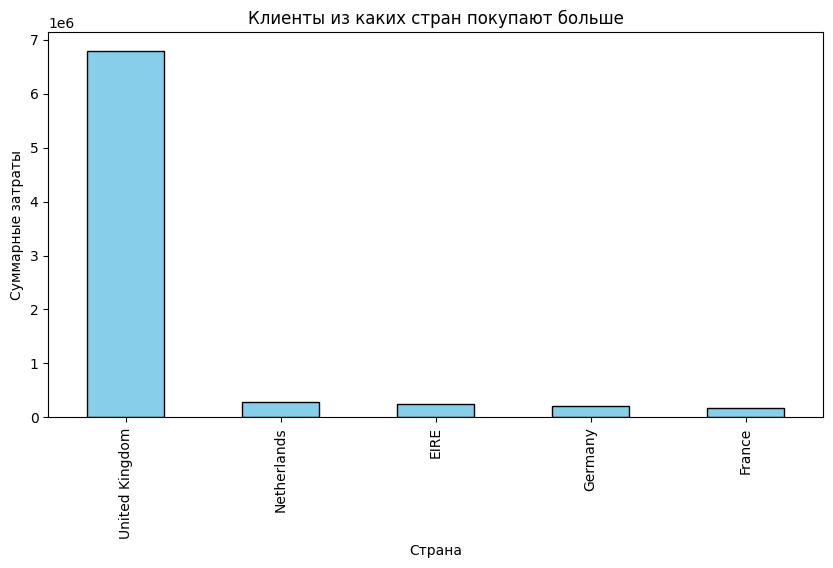

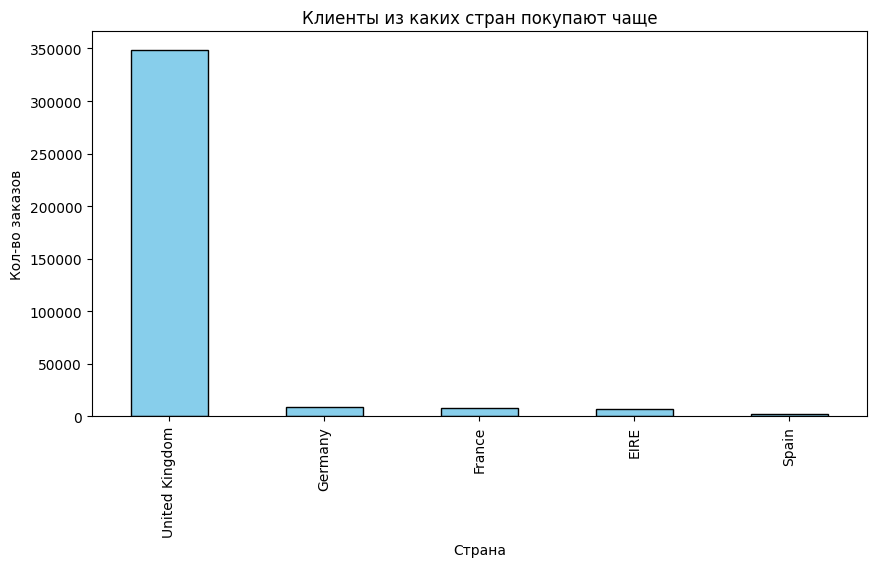

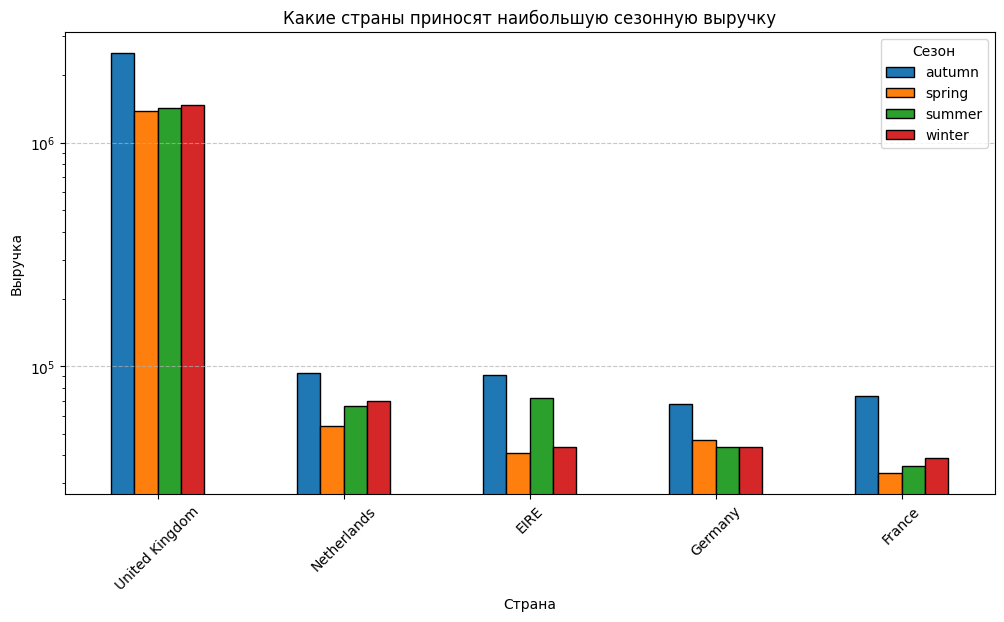

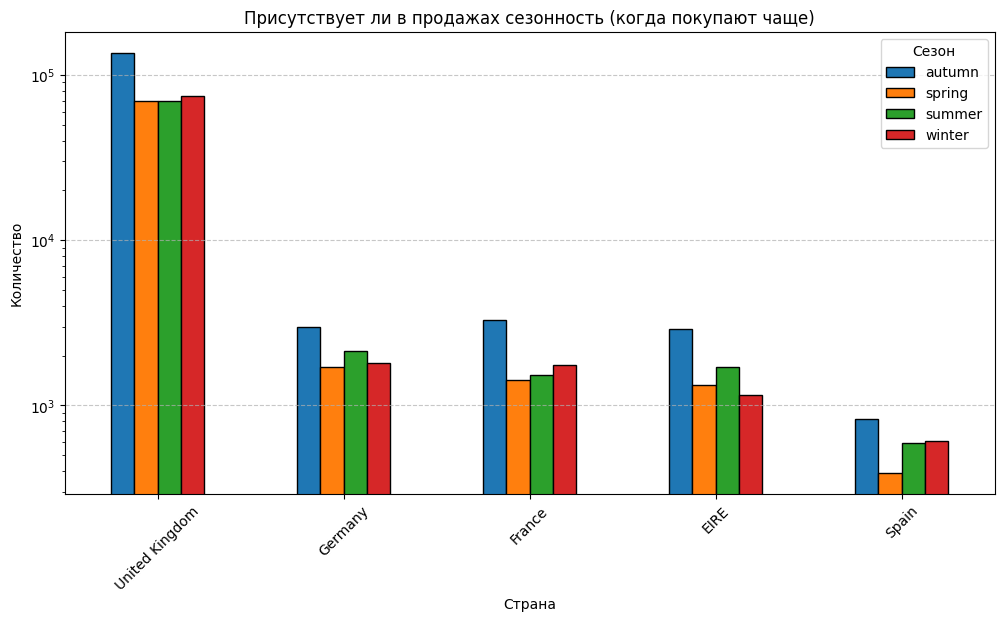

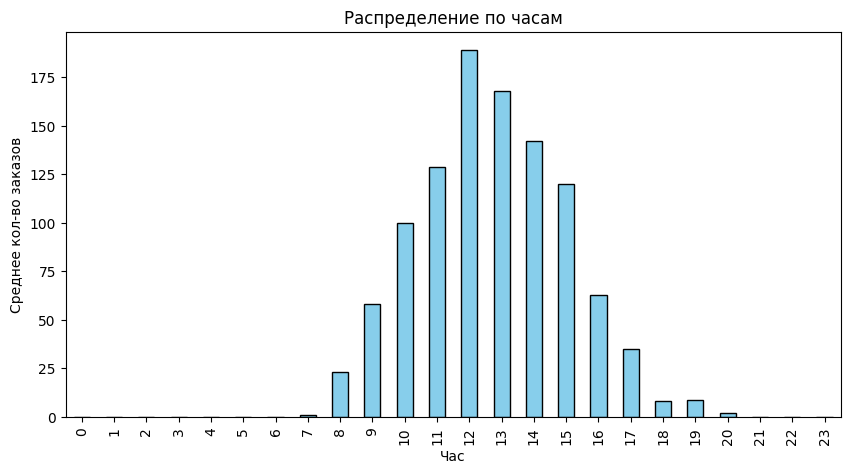

In [ ]:
#Клиенты из каких стран покупают больше и чаще?
#print('Clients from following countries spend more than others:', '\n', data.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10),'\n')
#Визуализация
data.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(5).plot.bar(color='skyblue', figsize=(10, 5))
# Добавляем подписи для ясности
plt.title('Клиенты из каких стран покупают больше')
plt.xlabel('Страна')
plt.ylabel('Суммарные затраты')
plt.show("png")

#print('Clients from following countries buy more frequently:', '\n', data.groupby('Country')['TotalPrice'].count().sort_values(ascending=False).head(),'\n')
#Визуализация
data.groupby('Country')['TotalPrice'].count().sort_values(ascending=False).head(5).plot.bar(color='skyblue', figsize=(10, 5))
# Добавляем подписи для ясности
plt.title('Клиенты из каких стран покупают чаще')
plt.xlabel('Страна')
plt.ylabel('Кол-во заказов')
plt.show("png")



# Какие страны приносят наибольшую сезонную выручку?
result = (
    data
    .groupby(['Country', 'Season'])['TotalPrice']
    .sum()
    .unstack(fill_value=0)
)

result['total'] = result.sum(axis=1) # добавим общий оборот
result = result.sort_values('total', ascending=False) # сортировка
result.columns.name = None
#print('Seasonality revenue:', '\n', result.head(5),'\n')
# Визуализация
result.iloc[:5,:-1].plot.bar(logy=True, figsize=(12, 6))
# Добавляем оформление
plt.title('Какие страны приносят наибольшую сезонную выручку')
plt.ylabel('Выручка')
plt.xlabel('Страна')
plt.xticks(rotation=45) # Поворачиваем названия стран для удобства
plt.legend(title='Сезон')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show("png")


# Присутствует ли в продажах сезонность (когда покупают чаще)?
result = (
    data
    .groupby(['Country', 'Season'])['TotalPrice']
    .count()
    .unstack(fill_value=0)
    )
result['total'] = result.sum(axis=1)
result = result.sort_values('total', ascending=False) # сортировка
result.columns.name = None
#Визуализация
result.iloc[:5,:-1].plot.bar(logy=True, figsize=(12, 6))
# Добавляем оформление
plt.title('Присутствует ли в продажах сезонность (когда покупают чаще)')
plt.ylabel('Количество')
plt.xlabel('Страна')
plt.xticks(rotation=45) # Поворачиваем названия стран для удобства
plt.legend(title='Сезон')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show("png")


# Находим количество заказов на каждый день-час. 
result = data.groupby(pd.Grouper(key="InvoiceDate", freq="H"))['TotalPrice'].count().reset_index()

# Находим среднее количество ежедневно поступающих заказов в каждый из часов
result["InvoiceDate"] = result["InvoiceDate"].dt.hour
result = result.groupby("InvoiceDate")['TotalPrice'].mean().round(0)
#print('Average order number per hour:', '\n', result,'\n')

#Визуализация
result.plot.bar(color='skyblue', figsize=(10, 5))
# Добавляем подписи для ясности
plt.title('Распределение по часам')
plt.xlabel('Час')
plt.ylabel('Среднее кол-во заказов')
plt.show("png")

Выводы: покупают больше и чаще клиенты из Соединенного королевства; сезонная выручка от клиентов из Соединенного королевства преобладает над выручкой полученной от клиентов из других стран; сезонность присутствует - осень пик продаж; суточная активность клиентов выявлена в диапазоне с 07.00 до 20.00 включительно (остальные часы активность равна 0), распределение близко к нормальному (Гауссовскому) с легкой правой асимметрией - колоколообразное.  

### 2.3. Построение RFM-таблицы и поиск RFM-выбросов

Мы добрались до самой интересной части нашей задачи. Нам предстоит сформировать признаки, на основе которых мы будем производить сегментацию клиентов.

Для этого давайте познакомимся с очень популярным методом для анализа потребительской ценности под названием RFM. 

<center> <img src=https://miro.medium.com/max/1400/1*uYQjy9SUjW7iWHc2gGanQQ.png align="right" width="400"/> </center>

Метод заключается в группировке клиентов на основе следующих параметров:
* Recency (Давность) — давность последней покупки клиента;
* Frequency (Частота) — общее количество покупок клиента;
* Monetary Value (Денежная ценность) — сколько денег потратил клиент.


Суть RFM-анализа состоит в том, что мы разделяем всех клиентов на группы в зависимости от того, как давно они сделали последнюю покупку, как часто покупали и насколько большой была сумма их заказов. 

Например, вот так может выглядеть интерпретация кластеров для случая RF-сегментации (анализа на основе давности и частоты заказов клиента):

<img src=https://retailrocket.ru/wp-content/uploads/2017/06/rfm-1.png>

Задача маркетологов — вести клиента в зону лояльных.

Мы можем рассчитать RFM-характеристики для каждого из клиентов в нашем датасете и на их основе с помощью методов кластеризации построить подобные сегменты клиентов, привязанные к нашим данным.

Чтобы получить RFM-таблицу, нам необходимо сгруппировать данные по идентификаторам клиента и рассчитать следующие  агрегированные характеристики:

* Recency для i-го клиента рассчитывается как разница между датой и временем последнего заказа и точкой отсчёта, переведённая в дни:
    $$t_0-max(t_{i1}, t_{i2},..., t_{iM})$$

    где $t_{ij}$ — дата и время совершения i-ым клиентом своей j-ой покупки.

    В качестве точки отсчёта $t_0$ берём дату на один день «старше», чем все наши данные. Это будет 10 декабря 2011 года (в формате datetime — '2011-12-10 00:00:00').

* Frequency рассчитывается как общее количество уникальных заказов, которые совершил i-ый клиент.
* Monetary Value рассчитывается как общая сумма денег, которую i-ый клиент потратил на наши товары (с учётом возвратов).

Когда вы рассчитаете все характеристики, не забудьте дать столбцам результирующей таблицы соответствующие названия.

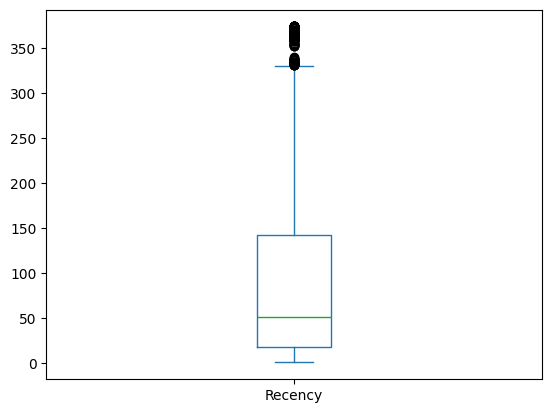

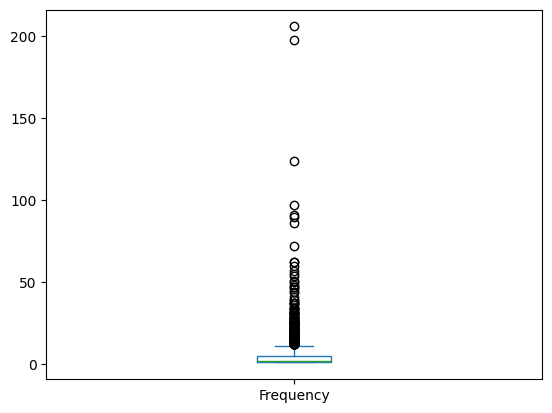

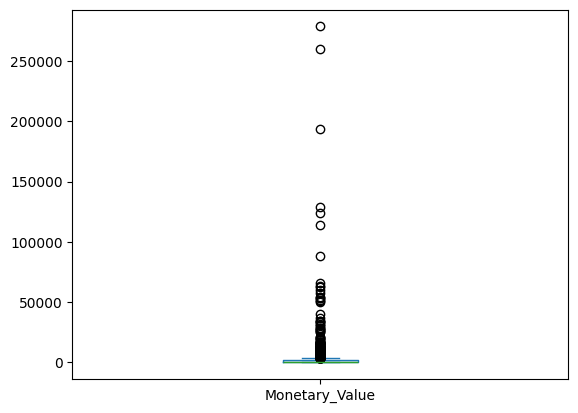

In [24]:
base_date = pd.to_datetime('2011-12-10 00:00:00')
rfm_table = data.groupby('CustomerID').agg(
    last_purchase=('InvoiceDate', 'max'),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary_Value=('TotalPrice', 'sum')
)
rfm_table['Recency'] = -(rfm_table['last_purchase'] - base_date).dt.days
rfm_table = pd.DataFrame(rfm_table[['Recency', 'Frequency', 'Monetary_Value']])
rfm_table = rfm_table.reset_index()
rfm_table['Recency'].plot.box()
plt.show()
rfm_table['Frequency'].plot.box()
plt.show()
rfm_table['Monetary_Value'].plot.box()
plt.show()

После того как вы подготовите RFM-таблицу, визуализируйте каждую из трёх компонент, например, в виде коробчатых диаграмм (boxplot). Вы получите примерно следующие результаты (графики могут отличаться в зависимости от того, как вы выполните предобработку данных):

In [ ]:
boxes = [px.box(rfm_table, x=column) for column in rfm_table.columns[1:]]
fig = make_subplots(
    rows=1, cols=3, 
    subplot_titles=(
        "Recency","Frequency", "Monetary_Value"
    )
)

for i, box in enumerate(boxes):
    fig.add_trace(boxes[i]['data'][0], row=1, col=i+1)

fig.update_layout(showlegend=True)
#fig.write_html('plotly/boxplot_1.html')
fig.show("png")

Что интересного здесь можно увидеть? Есть клиенты с аномально большим количеством сделанных заказов (более 100 штук), а также клиенты, общая стоимость заказов которых превышает 190 тысяч фунтов стерлингов.

Чем это плохо? Выбросы могут отрицательно сказаться на результатах работы методов кластеризации, неустойчивых к ним, например алгоритма KMeans, поэтому хотелось бы от них избавиться. Однако терять много ценных данных о клиентах тоже не хочется, поэтому ограничимся верхней границей соответствующей квантили уровня 0.95. Таким образом, мы удалим данные тех клиентов, для которых значение параметра Frequency или параметра Monetary выше, чем у 95 % клиентов.


In [26]:
# удаляем данные тех клиентов, для которых значение параметра Frequency или параметра Monetary выше, чем у 95 % клиентов
q_freq = rfm_table['Frequency'].quantile(0.95)
q_mon = rfm_table['Monetary_Value'].quantile(0.95)

cleaned = rfm_table[
    (rfm_table['Frequency'] <= q_freq) &
    (rfm_table['Monetary_Value'] <= q_mon)
]

outliers = rfm_table[
    (rfm_table['Frequency'] > q_freq) |
    (rfm_table['Monetary_Value'] > q_mon)
]
#cleaned.info()

## 3. Моделирование и оценка качества моделей

### 3.1. Кластеризация на основе RFM-характеристик

Чтобы результаты кластеризации было удобнее интерпретировать, вы можете уменьшить размерность исходных признаков до двух компонент.

**Подсказка.** Чтобы методы понижения размерности работали стабильно, данные необходимо стандартизировать/нормализовать. Для удобства оберните эти шаги по предобработке данных в pipeline.

Произведите предобработку исходных данных. На основе RFM-признаков кластеризуйте клиентов онлайн-магазина подарков с помощью известных вам методов (используйте минимум три метода).

Подберите оптимальное количество кластеров для выбранных методов с помощью коэффициента силуэта, перебирая возможные значения от 3 до 10 включительно (большее или меньшее количество кластеров будет нерелеватно для маркетинга). 

Выберите алгоритм с наибольшим коэффициентом силуэта, сделайте предсказание меток кластеров.


In [27]:
# =========================================================
# 1. Исходные данные
# =========================================================
rfm = cleaned.copy()

# CustomerID оставляем отдельно, в кластеризацию не включаем
customer_ids = rfm['CustomerID'].copy()

# признаки для кластеризации
X = rfm[['Recency', 'Frequency', 'Monetary_Value']].copy()


# =========================================================
# 2. Предобработка: стандартизация + PCA до 2 компонент
# =========================================================
preprocessor = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=42))
])

X_preprocessed = preprocessor.fit_transform(X)


# =========================================================
# 3. Функции оценки
# =========================================================
def evaluate_clustering(X_transformed, labels):
    """
    Возвращает silhouette score, если кластеризация валидна.
    Иначе np.nan.
    """
    unique_labels = np.unique(labels)

    # для DBSCAN может быть шум = -1
    # silhouette считаем только если есть минимум 2 кластера
    # и не все объекты попали в один кластер
    if len(unique_labels) < 2:
        return np.nan

    # если все точки шум или один кластер -> невалидно
    if len(set(labels)) < 2:
        return np.nan

    # silhouette корректно считать, если есть хотя бы 2 кластера
    try:
        score = silhouette_score(X_transformed, labels)
        return score
    except Exception:
        return np.nan


results = []


# =========================================================
# 4. KMeans: перебор k от 3 до 10
# =========================================================
for n_clusters in range(3, 11):
    model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = model.fit_predict(X_preprocessed)
    score = evaluate_clustering(X_preprocessed, labels)

    results.append({
        'algorithm': 'KMeans',
        'n_clusters': n_clusters,
        'params': {'n_clusters': n_clusters},
        'silhouette_score': score,
        'labels': labels,
        'model': model
    })


# =========================================================
# 5. Gaussian Mixture (EM): перебор k от 3 до 10
# =========================================================
for n_clusters in range(3, 11):
    model = GaussianMixture(n_components=n_clusters, random_state=42)
    model.fit(X_preprocessed)
    labels = model.predict(X_preprocessed)
    score = evaluate_clustering(X_preprocessed, labels)

    results.append({
        'algorithm': 'GaussianMixture',
        'n_clusters': n_clusters,
        'params': {'n_components': n_clusters},
        'silhouette_score': score,
        'labels': labels,
        'model': model
    })


# =========================================================
# 6. Agglomerative Clustering: перебор k от 3 до 10
# =========================================================
for n_clusters in range(3, 11):
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    labels = model.fit_predict(X_preprocessed)
    score = evaluate_clustering(X_preprocessed, labels)

    results.append({
        'algorithm': 'Agglomerative',
        'n_clusters': n_clusters,
        'params': {'n_clusters': n_clusters, 'linkage': 'ward'},
        'silhouette_score': score,
        'labels': labels,
        'model': model
    })


# =========================================================
# 7. DBSCAN
# =========================================================
# У DBSCAN нет параметра n_clusters, поэтому подбираем eps.
# Оставляем только те варианты, где число найденных кластеров от 3 до 10.
for eps in np.arange(0.1, 2.1, 0.1):
    for min_samples in [3, 5, 10, 15]:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_preprocessed)

        # число кластеров без учета шума (-1)
        cluster_labels = set(labels)
        n_clusters = len(cluster_labels - {-1})

        if 3 <= n_clusters <= 10:
            # silhouette для DBSCAN лучше считать без шума
            mask = labels != -1
            if mask.sum() > 1 and len(np.unique(labels[mask])) >= 2:
                score = evaluate_clustering(X_preprocessed[mask], labels[mask])
            else:
                score = np.nan

            results.append({
                'algorithm': 'DBSCAN',
                'n_clusters': n_clusters,
                'params': {'eps': round(eps, 2), 'min_samples': min_samples},
                'silhouette_score': score,
                'labels': labels,
                'model': model
            })


# =========================================================
# 8. Таблица результатов
# =========================================================
results_df = pd.DataFrame([
    {
        'algorithm': r['algorithm'],
        'n_clusters': r['n_clusters'],
        'params': r['params'],
        'silhouette_score': r['silhouette_score']
    }
    for r in results
])

results_df = results_df.sort_values(
    by='silhouette_score',
    ascending=False
).reset_index(drop=True)

pd.set_option('display.width', 140)
print("Результаты подбора моделей:\n")
print(results_df.round(4))


# =========================================================
# 9. Выбор лучшей модели
# =========================================================
best_result = max(results, key=lambda x: x['silhouette_score'] if pd.notna(x['silhouette_score']) else -np.inf)

print("\nЛучшая модель:")
print(f"Алгоритм: {best_result['algorithm']}")
print(f"Количество кластеров: {best_result['n_clusters']}")
print(f"Параметры: {best_result['params']}")
print(f"Silhouette score: {best_result['silhouette_score']:.4f}")


# =========================================================
# 10. Предсказание меток кластеров
# =========================================================
rfm_clustered = rfm.copy()
rfm_clustered['Cluster'] = best_result['labels']

print("\nПервые строки с метками кластеров:")
print(rfm_clustered.head(3))


# =========================================================
# 11. Сводка по кластерам для интерпретации
# =========================================================
cluster_summary = rfm_clustered.groupby('Cluster')[['Recency', 'Frequency', 'Monetary_Value']].mean()
cluster_sizes = rfm_clustered['Cluster'].value_counts().sort_index()

print("\nСредние значения RFM по кластерам:")
print(cluster_summary)

print("\nРазмеры кластеров:")
print(cluster_sizes)

Результаты подбора моделей:

          algorithm  n_clusters                                 params  silhouette_score
0            KMeans           3                      {'n_clusters': 3}            0.5242
1            KMeans           4                      {'n_clusters': 4}            0.4976
2     Agglomerative           3   {'n_clusters': 3, 'linkage': 'ward'}            0.4968
3            KMeans           5                      {'n_clusters': 5}            0.4547
4            KMeans           6                      {'n_clusters': 6}            0.4480
5     Agglomerative           5   {'n_clusters': 5, 'linkage': 'ward'}            0.4391
6   GaussianMixture           3                    {'n_components': 3}            0.4358
7            KMeans           8                      {'n_clusters': 8}            0.4294
8     Agglomerative           4   {'n_clusters': 4, 'linkage': 'ward'}            0.4253
9     Agglomerative           6   {'n_clusters': 6, 'linkage': 'ward'}           

### 3.2. Интерпретация результатов кластеризации

Перейдём к интерпретации полученных кластеров.

#### 3.2.1. Визуализация кластеров

Визуализируйте результаты в виде 3D-диаграммы с осями Recency, Frequency и Monetary. Проанализируйте полученную диаграмму и попробуйте понять, какие кластеры у вас получились.

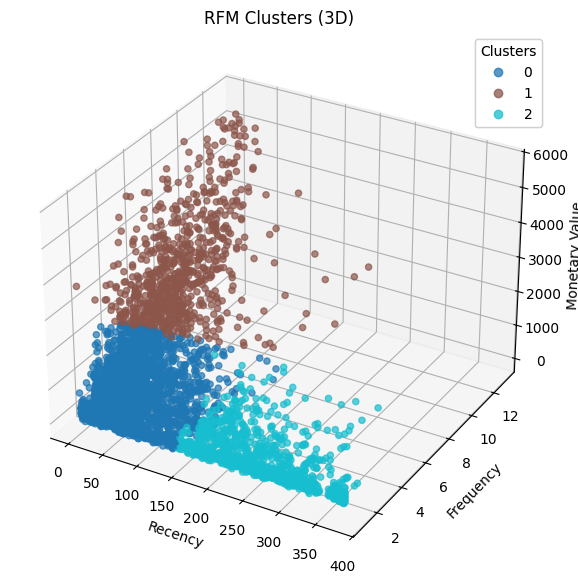

In [ ]:
# создаём фигуру
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# точки
scatter = ax.scatter(
    rfm_clustered['Recency'],
    rfm_clustered['Frequency'],
    rfm_clustered['Monetary_Value'],
    c=rfm_clustered['Cluster'],
    cmap='tab10',
    alpha=0.7
)

# подписи осей
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary Value')

# легенда
legend = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend)

plt.title('RFM Clusters (3D)')
plt.show("png")

Recency ↓ (меньше) → клиент недавно покупал → хорошо
Frequency ↑ → часто покупает → хорошо
Monetary ↑ → много тратит → очень хорошо

1. VIP / High-value -лучшие клиенты\ядро бизнеса
Recency: низкий
Frequency: высокий
Monetary: высокий

2. Loyal (частые, но средний чек) - значимая доля, нужно удерживать и стимулировать
Recency: низкий
Frequency: высокий
Monetary: средний

3. Big spenders (редкие, но дорогие покупки) - значимая доля, нужно удерживать и стимулировать повторные покупки
Recency: средний
Frequency: низкий
Monetary: высокий

4. At risk / churn - зона риска
Recency: высокий (давно не покупали)
Frequency: средний/низкий
Monetary: разный

5. Low-value - минимальный приоритет
Recency: высокий
Frequency: низкий
Monetary: низкий


#### 3.2.2. Построение профиля кластеров

Далее составьте так называемый профиль кластеров. Для этого вам необходимо вернуться от декомпозированных данных (если вы производили понижение размерности) к RFM-таблице (очищенной от выбросов).

Сгруппируйте RFM-таблицу по полученным кластерам и рассчитайте среднее по каждому из признаков.

Чтобы результаты было проще интерпретировать, давайте познакомимся с одним из способов визуализации профиля кластеров — **Radar Chart** (полярная диаграмма, или диаграмма паутины). Это графическое представление значений нескольких эквивалентных категорий в форме паутины.

Radar Chart часто используется при определении профиля кластеров. На концах паутины откладываются оси, соответствующие признакам, описывающим объекты. На каждой из осей для каждого кластера откладываются средние значения соответствующих характеристик. Соединив точки по осям, мы получаем многоугольник. 

Пример полярной диаграммы для задачи кластеризации учеников по интересам:

<img src=https://www.datanovia.com/en/wp-content/uploads/2020/12/radar-chart-in-r-customized-fmstb-radar-chart-1.png width=500>

На этой диаграмме мы видим визуализацию признаков для одного из кластеров. Видно, что ученики, принадлежащие этому кластеру, в большей степени увлекаются музыкой (Music), а в меньшей — программированием (Programm).

В модуле `graph_objects` библиотеки `plotly` есть встроенная функция `Scatterpolar`, которая позволяет построить полярную диаграмму. На основе этой функции мы подготовили для вас функцию `plot_cluster_profile()`, которая позволяет визуализировать профиль каждого из кластеров в виде полярной диаграммы. У неё есть два параметра: `grouped_data` — сгруппированные по кластерам характеристики объектов (клиентов), `n_clusters` — количество кластеров.

Главное условие использования полярной диаграммы — все признаки должны быть приведены к единому масштабу с помощью нормализации, где 1 будет означать максимум, а 0 — минимум. Шаг с нормализацией мы также добавили в функцию `plot_cluster_profile()`.


In [ ]:
def plot_cluster_profile(grouped_data, n_clusters):
    """Функция для визуализации профиля кластеров в виде полярной диаграммы.

    Args:
        grouped_data (DataFrame): таблица, сгруппированная по номерам кластеров с агрегированными характеристиками объектов.
        n_clusters (int): количество кластеров
    """
    # Нормализуем сгруппированные данные, приводя их к масштабу 0-1.
    scaler = MinMaxScaler()
    grouped_data = pd.DataFrame(scaler.fit_transform(grouped_data), columns=grouped_data.columns)
    # Создаём список признаков
    features = grouped_data.columns
    # Создаём пустую фигуру
    fig = go.Figure()
    # В цикле визуализируем полярную диаграмму для каждого кластера
    for i in range(n_clusters):
        # Создаём полярную диаграмму и добавляем её на общий график
        fig.add_trace(go.Scatterpolar(
            r=grouped_data.iloc[i].values, # радиусы
            theta=features, # название засечек
            fill='toself', # заливка многоугольника цветом
            name=f'Cluster {i}', # название — номер кластера
        ))
    # Обновляем параметры фигуры
    fig.update_layout(
        showlegend=True, # отображение легенды
        autosize=False, # устаналиваем свои размеры графика
        width=800, # ширина (в пикселях)
        height=800, # высота (в пикселях)
    )
    # Отображаем фигуру
    fig.show("png")

Теперь у вас есть удобный инструмент для анализа профиля кластеров. Воспользуйтесь им, чтобы проинтерпретировать результаты, полученные на предыдущем шаге.

In [30]:
#группируем RFM-таблицу по полученным кластерам
X_cleaned = cleaned[['Recency', 'Frequency', 'Monetary_Value']].copy() #здесь берем ненормалтзованный, но очищенный датафрейм
X_PCA = PCA(n_components=2, random_state=42).fit_transform(X_cleaned)

model = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = model.fit_predict(X_PCA)

X_cleaned['Cluster'] = labels
cluster_profile = (
    X_cleaned
    .groupby('Cluster')[['Recency', 'Frequency', 'Monetary_Value']]
    .mean()
    .sort_index()
)

In [31]:
plot_cluster_profile(cluster_profile, 3)

## 4. Выводы и оформление работы

Напишите заключение о проделанной работе и полученных результатах. Отметьте, какие сегменты клиентов вам удалось найти в данных.

После завершения проекта создайте в своём репозитории файл README.md и кратко опишите содержимое проекта по принципу, который мы приводили ранее.

Выложите свой проект на GitHub и оформите удалённый репозиторий, добавив в него описание и теги репозитория (теги придумайте самостоятельно в зависимости от того, какую задачу вы решали).

Итоги: из исходных данных после анализа, очистки, добавления новых признаков была производена кластеризации. На ее основе приозведен сегментация и интерпретация клиентов на предмет фокуса для дальнейшего стимулирования. 
Используя Radar Chart была произведена отрисовка кластеров.

Набор и последовательность действий, использованные для реализации проекта, готовы для практического применения (в поле) в E-commerce секторе.


GitHub link: https://github.com/Lepnik/data_science_lnv/blob/main/MATH%2BML/Project_6/E-shop/README.md